# Notebook for practical exercises | Week #5 Lesson #1

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Assessing Fairness and Bias*.

After this session, you will know how to analyze the results of a classification model regarding fairness on a real-world clinical problem:
* Comparing performance of a model across groups of population ; 
* Implement a resampling and/or data augmentation strategy to mitigate biases ;
* Reporting fairness evaluation metrics.

## Dataset

ChestX-ray dataset comprises 112,120 frontal-view X-ray images of 30,805 unique patients with the text-mined fourteen disease image labels (where each image can have multi-labels), mined from the associated radiological reports using natural language processing.
Fourteen common thoracic pathologies include Atelectasis, Consolidation, Infiltration, Pneumothorax, Edema, Emphysema, Fibrosis, Effusion, Pneumonia, Pleural_thickening, Cardiomegaly, Nodule, Mass and Hernia. 

It initially contains:
1. 112,120 frontal-view chest X-ray PNG images in 1024*1024 resolution (under images folder)
2. Meta data for all images (Data_Entry_2017.csv): Image Index, Finding Labels, Follow-up #, Patient ID, Patient Age, Patient Gender, View Position, Original Image Size and Original Image Pixel Spacing.
3. Bounding boxes for ~1000 images (BBox_List_2017.csv): Image Index, Finding Label, Bbox[x, y, w, h]. [x y] are coordinates of each box's topleft corner. [w h] represent the width and height of each box.
4. Two data split files (train_val_list.txt and test_list.txt) are provided. Images in the ChestX-ray dataset are divided into these two sets on the patient level. All studies from the same patient will only appear in either training/validation or testing set.

Here, we will use a subsample of this dataset along with pretrained models. Our goal is to analyse the behavior of a model across population groups.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from glob import glob
import warnings

warnings.filterwarnings(action="ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import tv_tensors
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

from PIL import Image


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

### Download

If needed, run the following cells to download and unzip the dataset. 

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
<b>If you have already downloaded the dataset, comment the following cell by adding a <code>#</code> before the <code>!</code></b>
</div>

In [56]:
DATA_PATH = '../..'
# !curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
# !unzip {DATA_PATH}/data.zip -d {DATA_PATH}

In [57]:
# Load and observe available data
metadata_df = pd.read_csv(f'{DATA_PATH}/data/CXR8/metadata.csv')
metadata_df#.head() # Print the 5 fist rows of the dataframe

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168
...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,38,M,PA,2048,2500,0.168,0.168
112116,00030802_000.png,No Finding,0,30802,28,M,PA,2048,2500,0.168,0.168
112117,00030803_000.png,No Finding,0,30803,42,F,PA,2048,2500,0.168,0.168
112118,00030804_000.png,No Finding,0,30804,29,F,PA,2048,2500,0.168,0.168


In this dataset, we have access to a few elements that allow us to group patient across categories: 
* `Age`
* `Sex/Gender`
* `Race/Ethnicity`

We will first visualize the number of patients within each group. 

In [58]:
metadata_df.groupby(['Patient Sex']).count()['Patient ID']

Patient Sex
F    48780
M    63340
Name: Patient ID, dtype: int64

In [59]:
# Define broader bins
bins = [0, 50, 100]
labels = ['<50', '50+']

# Create age group column
metadata_df['Age Group'] = pd.cut(metadata_df['Patient Age'], bins=bins, labels=labels, right=False)

# Count number of cases per age group
metadata_df.groupby('Age Group')['Patient ID'].count()

Age Group
<50    58341
50+    53779
Name: Patient ID, dtype: int64

## Loading pretrained model  

In [60]:
from torchvision.models import mobilenet_v3_small

imgs = glob(f'{DATA_PATH}/data/CXR8/images/*')
imgs_basename = [os.path.basename(i) for i in imgs]

metadata_df = metadata_df.loc[metadata_df['Image Index'].isin(imgs_basename)]

In [61]:
metadata_df['Pathology'] = [0 if l == 'No Finding' else 1 for l in metadata_df['Finding Labels'].tolist()]

In [62]:
metadata_df.groupby(['Age Group', 'Pathology']).count()['Patient ID']

Age Group  Pathology
<50        0            1138
           1             867
50+        0            1616
           1            1378
Name: Patient ID, dtype: int64

In [64]:
patient_ids = metadata_df['Patient ID'].unique()

patient_train, patient_test = train_test_split(
    patient_ids, # List or array to split
    test_size=0.2, # Size of the subset
    random_state=42)


patient_train, patient_val = train_test_split(
    patient_train, # List or array to split
    test_size=0.1, # Size of the subset
    random_state=42)

train_df = metadata_df.loc[metadata_df['Patient ID'].isin(patient_train)]
val_df = metadata_df.loc[metadata_df['Patient ID'].isin(patient_val)]
test_df = metadata_df.loc[metadata_df['Patient ID'].isin(patient_test)]


train_df = pd.concat([train_df.loc[(train_df['Age Group']=='50+') & (train_df['Pathology']==1)].sample(800),
                      train_df.loc[(train_df['Age Group']=='50+') & (train_df['Pathology']==0)].sample(800),
                      train_df.loc[(train_df['Age Group']=='<50') & (train_df['Pathology']==1)].sample(200),
                      train_df.loc[(train_df['Age Group']=='<50') & (train_df['Pathology']==0)].sample(200),
                     ])

In [65]:
train_df.groupby(['Patient Sex']).count()['Patient ID']

Patient Sex
F    1070
M     930
Name: Patient ID, dtype: int64

In [67]:
train_df.groupby(['Age Group', 'Pathology']).count()['Patient ID']

Age Group  Pathology
<50        0            200
           1            200
50+        0            800
           1            800
Name: Patient ID, dtype: int64

In [68]:
class ClassificationDataset(Dataset):
    def __init__(self, dataframe, image_dir, train=False):
        super().__init__()
        self.df = dataframe
        self.image_ids = self.df['Image Index'].tolist()
        self.subject_ids = self.df['Patient ID'].tolist()
        self.labels = self.df['Pathology'].tolist()
        self.age = self.df['Age Group'].tolist()
        self.sex = self.df['Patient Sex'].tolist()
        self.image_dir = image_dir
        self.size = 256

        if train:
            self.transforms_img = torchvision.transforms.Compose([
                torchvision.transforms.Resize((self.size, self.size)),
                torchvision.transforms.RandomAdjustSharpness(sharpness_factor=2),
                torchvision.transforms.ToTensor(),
                lambda x : x / (x.max() + 1e-6),
                torchvision.transforms.Normalize((0.5,), (0.2,)),
            ])
        else: 
            self.transforms_img = torchvision.transforms.Compose([
                torchvision.transforms.Resize((self.size, self.size)),
                torchvision.transforms.ToTensor(),
                lambda x : x / (x.max() + 1e-6),
                torchvision.transforms.Normalize((0.5,), (0.2,))
            ])

    def __getitem__(self, index: int):
        image_id = self.image_ids[index]
        target = self.labels[index]
        
        image_path = f'{self.image_dir}/{image_id}'
        image = Image.open(image_path)

        if image.mode != 'L':
            image = image.convert('L')
        
        image = self.transforms_img(image)
        target = torch.tensor(target)

        return image, target

    def __len__(self) -> int:
        return len(self.image_ids)

In [69]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

def train_loop_cls(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    # Set the model to training mode
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        pred = nn.functional.sigmoid(pred)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return model

def val_loop_cls(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            pred = nn.functional.sigmoid(pred)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Validation: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct

In [70]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import time
torch.mps.empty_cache()

train_dataset_cls = ClassificationDataset(
    train_df, 
    f'{DATA_PATH}/data/CXR8/images',
    train = True
)

val_dataset_cls = ClassificationDataset(
    val_df, 
    f'{DATA_PATH}/data/CXR8/images'
)

learning_rate = 1e-3
batch_size = 16
epochs = 20

model_enb0 = efficientnet_b0(weights='DEFAULT')
model_enb0.classifier[1] = nn.Linear(1280, 2)
model_enb0.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

train_dataloader = DataLoader(train_dataset_cls, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset_cls, batch_size=1)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_enb0.parameters(), lr=learning_rate) 
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)

model_enb0.to(device)
loss_fn.to(device)

s = time.process_time() # start time

best_acc = 0
best_model = None

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    model_enb0 = train_loop_cls(train_dataloader, model_enb0, loss_fn, optimizer, device)
    lr_scheduler.step()
    test_acc = val_loop_cls(val_dataloader, model_enb0, loss_fn, device)
    
    if test_acc > best_acc:
        best_acc = test_acc
        best_model = model_enb0
print("Done!")

torch.save(best_model.state_dict(), './efficientnetb0-pathology-cxr8.pth')

e = time.process_time() # end time
print(e - s, "seconds")

Epoch 1
-------------------------------
loss: 0.683236  [   16/ 2000]
loss: 0.566171  [ 1616/ 2000]
Validation: 
 Accuracy: 50.6%, Avg loss: 0.726367 

Epoch 2
-------------------------------
loss: 0.553401  [   16/ 2000]
loss: 0.656926  [ 1616/ 2000]
Validation: 
 Accuracy: 65.3%, Avg loss: 0.629675 

Epoch 3
-------------------------------
loss: 0.672700  [   16/ 2000]
loss: 0.693883  [ 1616/ 2000]
Validation: 
 Accuracy: 63.7%, Avg loss: 0.632996 

Epoch 4
-------------------------------
loss: 0.646163  [   16/ 2000]
loss: 0.521552  [ 1616/ 2000]
Validation: 
 Accuracy: 64.6%, Avg loss: 0.648019 

Epoch 5
-------------------------------
loss: 0.725342  [   16/ 2000]
loss: 0.698449  [ 1616/ 2000]
Validation: 
 Accuracy: 66.2%, Avg loss: 0.614099 

Epoch 6
-------------------------------
loss: 0.696248  [   16/ 2000]
loss: 0.533668  [ 1616/ 2000]
Validation: 
 Accuracy: 68.2%, Avg loss: 0.609769 

Epoch 7
-------------------------------
loss: 0.582490  [   16/ 2000]
loss: 0.362919  [ 

In [50]:
# # Train models only on M or F
# from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
# import time
# torch.mps.empty_cache()

# train_dataset_cls = ClassificationDataset(
#     train_df.loc[train_df['Age Group']=='40+'], 
#     f'{DATA_PATH}/data/CXR8/images',
#     train = True
# )

# val_dataset_cls = ClassificationDataset(
#     val_df.loc[val_df['Age Group']=='40+'], 
#     f'{DATA_PATH}/data/CXR8/images'
# )

# learning_rate = 1e-3
# batch_size = 32
# epochs = 20

# model_enb0 = efficientnet_b0(weights='DEFAULT')
# model_enb0.classifier[1] = nn.Linear(1280, 2)
# model_enb0.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

# train_dataloader = DataLoader(train_dataset_cls, batch_size=batch_size, shuffle=True)
# val_dataloader = DataLoader(val_dataset_cls, batch_size=1)

# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model_enb0.parameters(), lr=learning_rate) # torch.optim.SGD(model_enb0.parameters(), lr = learning_rate)#
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0)

# model_enb0.to(device)
# loss_fn.to(device)

# s = time.process_time() # start time

# best_acc = 0
# best_model = None

# # for t in range(epochs):
# #     print(f"Epoch {t+1}\n-------------------------------")
# #     model_enb0 = train_loop_cls(train_dataloader, model_enb0, loss_fn, optimizer, device)
# #     lr_scheduler.step()
# #     test_acc = val_loop_cls(val_dataloader, model_enb0, loss_fn, device)
    
# #     if test_acc > best_acc:
# #         best_acc = test_acc
# #         best_model = model_enb0
# # print("Done!")

# # torch.save(best_model.state_dict(), './efficientnetb0-pathology-cxr8-M.pth')

# e = time.process_time() # end time
# print(e - s, "seconds")

## Compare performance across genders

In [51]:
def test(model_enb0, test_dataset, device):
    test_dataloader = DataLoader(test_dataset, batch_size=1)
    
    model_enb0.eval()
    model_enb0.to(device)
    
    preds_list = []
    probs_list = []
    label_list = []
    
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            out = model_enb0(X)
    
            probs = nn.functional.softmax(out, dim=1)  # use softmax for multi-logit outputs
            preds = probs.argmax(dim=1)
    
            probs_list.append(probs[:, 1].item())  # probability for class 1
            preds_list.append(preds.item())
            label_list.append(y.detach().cpu().numpy())
    
    display = RocCurveDisplay.from_predictions(
    label_list,
    probs_list,
    name=f"Pneumonia vs. rest",
    color="darkorange",
    plot_chance_level=True,
    )
    _ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Binary classification",
    )
    display.ax_.legend(frameon=False)
    
    print(
    f'Model EN-B0:',
    '\nAccuracy:', accuracy_score(label_list, preds_list),
    '\nF1-score:', f1_score(label_list, preds_list),
    '\nRecall:', recall_score(label_list, preds_list),
    '\nPrecision:', precision_score(label_list, preds_list)
    )

Model EN-B0: 
Accuracy: 0.5774647887323944 
F1-score: 0.5740365111561867 
Recall: 0.6021276595744681 
Precision: 0.5484496124031008


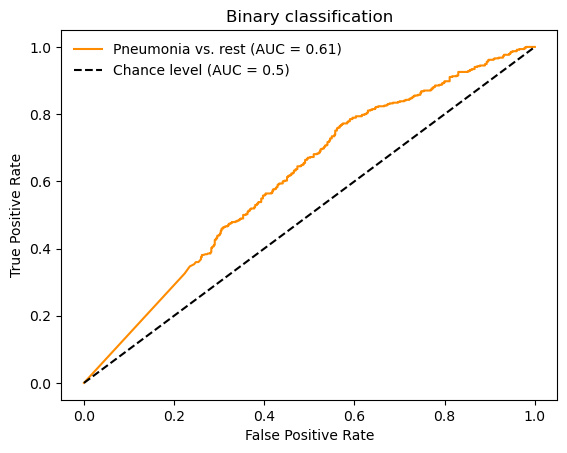

In [52]:
model_enb0 = efficientnet_b0()
model_enb0.classifier[1] = nn.Linear(1280, 2)
model_enb0.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
model_enb0.load_state_dict(torch.load('./efficientnetb0-pathology-cxr8.pth'))

test_dataset = ClassificationDataset(
    test_df, 
    f'{DATA_PATH}/data/CXR8/images'
)
test(model_enb0, test_dataset, device)

Model EN-B0: 
Accuracy: 0.5662650602409639 
F1-score: 0.625 
Recall: 0.7105263157894737 
Precision: 0.5578512396694215


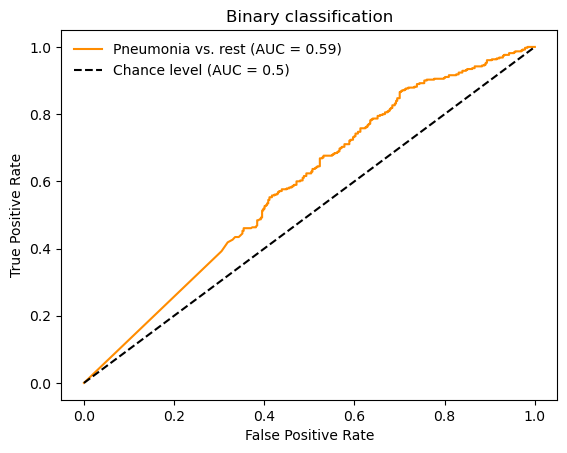

In [53]:
test_dataset = ClassificationDataset(
    test_df.loc[test_df['Age Group']=='50+'], 
    f'{DATA_PATH}/data/CXR8/images'
)
test(model_enb0, test_dataset, device)

Model EN-B0: 
Accuracy: 0.611336032388664 
F1-score: 0.21311475409836064 
Recall: 0.14444444444444443 
Precision: 0.40625


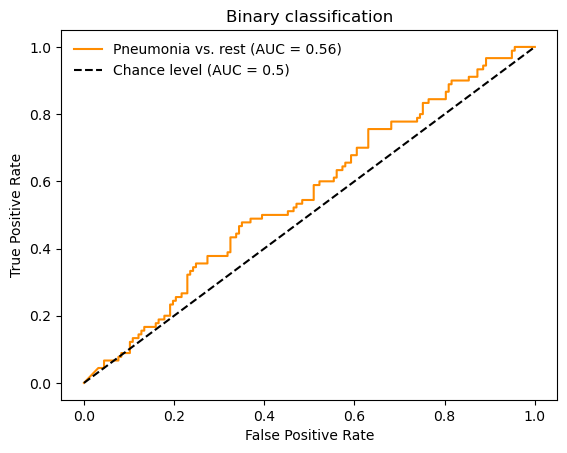

In [54]:
test_dataset = ClassificationDataset(
    test_df.loc[test_df['Age Group']=='<50'], 
    f'{DATA_PATH}/data/CXR8/images'
)
test(model_enb0, test_dataset, device)

In [53]:
from sklearn.metrics import confusion_matrix

def compute_AOD_EOD_from_split(y_true_F, y_pred_F, y_true_M, y_pred_M):
    # Helper to compute TPR and FPR
    def group_rates(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn + 1e-6)
        fpr = fp / (fp + tn + 1e-6)
        return tpr, fpr

    tpr_F, fpr_F = group_rates(y_true_F, y_pred_F)
    tpr_M, fpr_M = group_rates(y_true_M, y_pred_M)

    # Equal Opportunity Difference = |TPR_F - TPR_M|
    EOD = abs(tpr_F - tpr_M)

    # Average Odds Difference = 0.5 * (|FPR_F - FPR_M| + |TPR_F - TPR_M|)
    AOD = 0.5 * (abs(fpr_F - fpr_M) + EOD)

    return {
        'TPR_F': tpr_F,
        'TPR_M': tpr_M,
        'FPR_F': fpr_F,
        'FPR_M': fpr_M,
        'EOD': EOD,
        'AOD': AOD
    }

In [54]:
compute_AOD_EOD_from_split(binary_labels_F, binary_preds_F, binary_labels_M, binary_preds_M)

{'TPR_F': 0.8333331944444675,
 'TPR_M': 0.8181817438016598,
 'FPR_F': 0.0,
 'FPR_M': 0.4999999375000079,
 'EOD': 0.015151450642807762,
 'AOD': 0.2575756940714078}

## Compare performance across age groups